In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

### Figure 2A :Comparing model TCGA bulk and single cells

/tmp/ipykernel_1495946/3330532265.py:82: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(


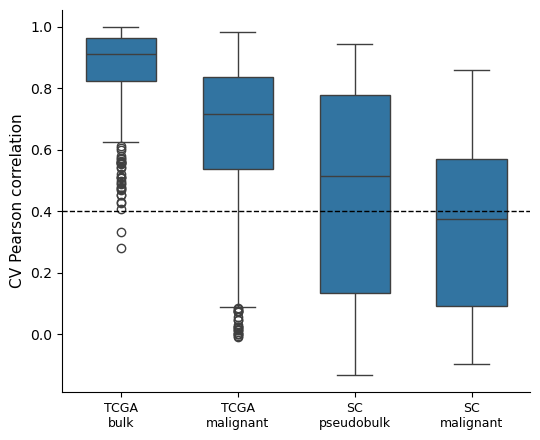

In [2]:
#df_merge_bulk_pseudo_bulk=pd.read_csv("/data/kumarr17/figures_to_upload/supplementray_table/CV_tcga_bulk_sc_pseudobulk.csv")
df_merge_bulk_pseudo_bulk=pd.read_csv("/data/kumarr17/TxCyto/results/CV_tcga_bulk_sc_pseudobulk.csv")

# ============================================================
# 1. Prepare data
# ============================================================

df = df_merge_bulk_pseudo_bulk

df_long = df[
    [
        "cv_tcga_bulk",
        "cv_tcga_epi",
        "cv_sc_pseudobulk",
        "cv_sc_epi"
    ]
].melt(
    var_name="Model",
    value_name="CV_accuracy"
)

# Cleaner model names
df_long["Model"] = df_long["Model"].replace({
    "cv_tcga_bulk": "TCGA bulk",
    "cv_tcga_epi": "TCGA epithelial",
    "cv_sc_pseudobulk": "SC pseudobulk",
    "cv_sc_epi": "SC epithelial"
})

# Explicit order
order = [
    "TCGA bulk",
    "TCGA epithelial",
    "SC pseudobulk",
    "SC epithelial"
]


# ============================================================
# 2. Create figure
# ============================================================

fig, ax = plt.subplots(figsize=(5.5, 4.5))

sns.boxplot(
    data=df_long,
    x="Model",
    y="CV_accuracy",
    order=order,
    showfliers=True,
    width=0.6,
    linewidth=1,
    ax=ax
)




# ============================================================
# 3. Reference line
# ============================================================

ax.axhline(
    y=0.4,
    color="black",
    linestyle="--",
    linewidth=1
)


# ============================================================
# 4. Axis formatting
# ============================================================

ax.set_xlabel("")

ax.set_ylabel(
    "CV Pearson correlation",
    fontsize=11
)

ax.set_xticklabels(
    [
        "TCGA\nbulk",
        "TCGA\nmalignant",
        "SC\npseudobulk",
        "SC\nmalignant"
    ],
    fontsize=9
)

ax.tick_params(
    axis="y",
    labelsize=10
)


# ============================================================
# 5. Figure formatting
# ============================================================

sns.despine(ax=ax)

ax.grid(False)

plt.tight_layout()


# ============================================================
# 6. Save as vector SVG
# ============================================================

#fig.savefig(
#    "/data/kumarr17/figures_to_upload/Figure2/CV_accuracy_TCGA_vs_single_cell_models.svg",
#    format="svg",
#    bbox_inches="tight",
#    pad_inches=0.05
#)

plt.show()

### Supplementray Figure 2: Single cell fraction of diffferent cell population

     Cell_type    Count  Percentage
0   Epithelial  1108440   26.728881
1         CD8T   700613   16.894556
2         CD4T   667707   16.101062
3      Myeloid   636850   15.356977
4      B cells   357835    8.628820
5      Stromal   289835    6.989070
6          ILC   210520    5.076471
7  Endothelial   175175    4.224163


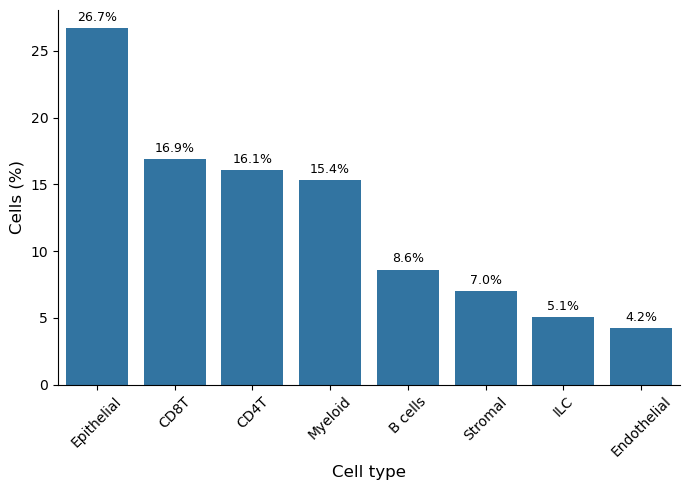

In [3]:
# ============================================================
# 1. CREATE DATAFRAME
# ============================================================

data = {
    "Epithelial": 1108440,
    "CD8T": 700613,
    "CD4T": 667707,
    "Myeloid": 636850,
    "B cells": 357835,
    "Stromal": 289835,
    "ILC": 210520,
    "Endothelial": 175175
}

df_cell = pd.DataFrame(
    list(data.items()),
    columns=["Cell_type", "Count"]
)

# ============================================================
# 2. CALCULATE PERCENTAGE
# ============================================================

df_cell["Percentage"] = (
    df_cell["Count"] / df_cell["Count"].sum()
) * 100

# Sort highest to lowest
df_cell = (
    df_cell
    .sort_values("Percentage", ascending=False)
    .reset_index(drop=True)
)

print(df_cell)


# ============================================================
# 3. BAR PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))

sns.barplot(
    data=df_cell,
    x="Cell_type",
    y="Percentage",
    order=df_cell["Cell_type"],
    ax=ax
)

# Labels
ax.set_xlabel("Cell type", fontsize=12)
ax.set_ylabel("Cells (%)", fontsize=12)

ax.tick_params(
    axis="x",
    rotation=45,
    labelsize=10
)

ax.tick_params(
    axis="y",
    labelsize=10
)

# Add percentage above bars
for container in ax.containers:
    labels = [
        f"{x:.1f}%"
        for x in df_cell["Percentage"]
    ]

    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=9
    )

# Clean figure
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()


# ============================================================
# 4. SAVE Figure
# ============================================================

#plt.savefig(
#    "/data/kumarr17/figures_to_upload/suplementary_figures/majorCluster_cell_percentage.svg",
#    format="svg",
#    bbox_inches="tight"
#)

#plt.savefig(
#    "/data/kumarr17/figures_to_upload/suplementary_figures/majorCluster_cell_percentage.pdf",
#    format="pdf",
#    bbox_inches="tight"
#)

plt.show()